In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import mne

# so notebook can find src/
sys.path.append("..")

from src.fft_helpers_2 import load_subject, preprocess_trial, precompute_bins, snr_score, fft_scores, predict_fft, evaluate_subject, compute_fft, plot_fft_all_channels

from src.config import FS, STIM_ONSET, CH_NAMES, TARGET_FREQS

# Test for a single person 


In [2]:
DATA_PATH = "../data/s5.mat"

eeg = load_subject(DATA_PATH)
print("EEG shape:", eeg.shape)

# 12 targets , 8 channels, 1114 time points, 15 trials

EEG shape: (12, 8, 1114, 15)


In [3]:
target_idx = 3
trial_idx = 11

trial = eeg[target_idx, :, :, trial_idx]
print("One raw trial shape:", trial.shape)

One raw trial shape: (8, 1114)


In [4]:
trial = eeg[target_idx, :, STIM_ONSET:, trial_idx]
print("After onset crop:", trial.shape)

trial_filt = preprocess_trial(trial, fs=FS)
print("Filtered trial shape:", trial_filt.shape)

After onset crop: (8, 1075)
Filtered trial shape: (8, 1075)


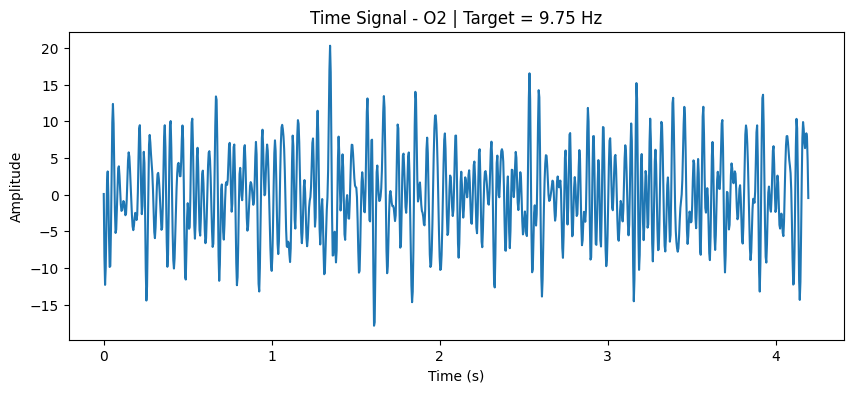

In [5]:
channel_idx = 7

x = trial_filt[channel_idx]
t = np.arange(len(x)) / FS

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Time Signal - {CH_NAMES[channel_idx]} | Target = {TARGET_FREQS[target_idx]} Hz")
plt.show()

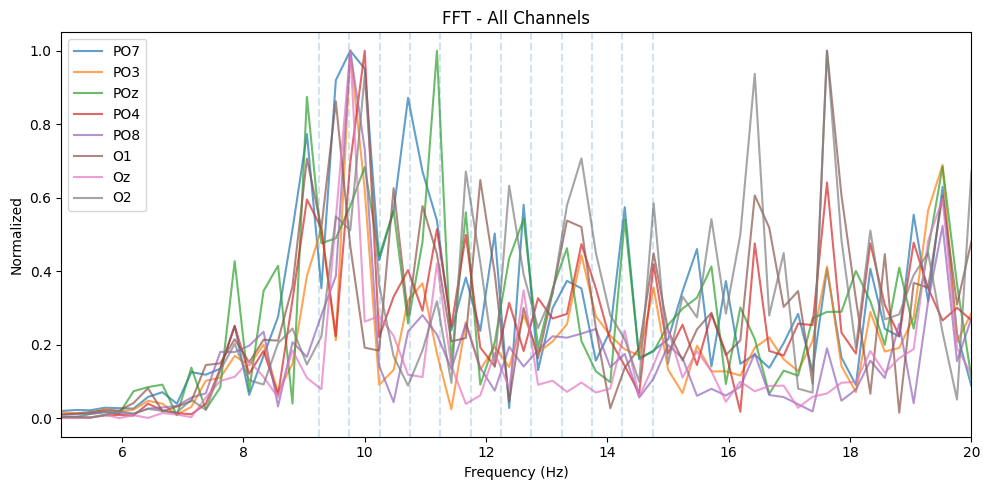

In [6]:
plot_fft_all_channels(
    trial_filt,
    fs=FS,
    ch_names=CH_NAMES,
    target_freq=None,
    target_freqs=TARGET_FREQS,
    normalize=True,
)

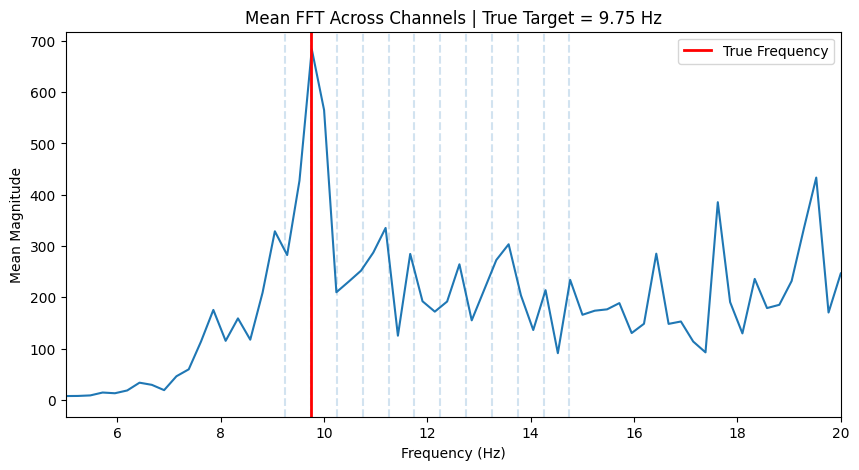

In [7]:
freqs, fft_vals = compute_fft(trial_filt, fs=FS)
mean_spectrum = fft_vals.mean(axis=0)

plt.figure(figsize=(10, 5))
plt.plot(freqs, mean_spectrum)
plt.xlim(5, 20)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean Magnitude")
plt.title(f"Mean FFT Across Channels | True Target = {TARGET_FREQS[target_idx]} Hz")

for f in TARGET_FREQS:
    plt.axvline(f, linestyle="--", alpha=0.2)

plt.axvline(TARGET_FREQS[target_idx], color="red", linewidth=2, label="True Frequency")
plt.legend()
plt.show()

In [8]:
bins=precompute_bins(trial_filt.shape[1], FS)

In [9]:
scores = fft_scores(trial_filt, bins)

for i, (f, s) in enumerate(zip(TARGET_FREQS, scores)):
    print(f"Class {i:2d} | Frequency {f:5.2f} Hz | Score = {s:.4f}")

Class  0 | Frequency  9.25 Hz | Score = 0.8308
Class  1 | Frequency 11.25 Hz | Score = -0.2362
Class  2 | Frequency 13.25 Hz | Score = 0.4874
Class  3 | Frequency  9.75 Hz | Score = 1.4103
Class  4 | Frequency 11.75 Hz | Score = 0.0516
Class  5 | Frequency 13.75 Hz | Score = 0.4580
Class  6 | Frequency 10.25 Hz | Score = 0.2682
Class  7 | Frequency 12.25 Hz | Score = -0.4535
Class  8 | Frequency 14.25 Hz | Score = -0.5461
Class  9 | Frequency 10.75 Hz | Score = -0.2186
Class 10 | Frequency 12.75 Hz | Score = 0.1055
Class 11 | Frequency 14.75 Hz | Score = -0.3075


In [10]:
pred_idx = predict_fft(trial_filt, bins)

print("True target index:     ", target_idx)
print("True target frequency: ", TARGET_FREQS[target_idx], "Hz")
print("Predicted target index:", pred_idx)
print("Predicted frequency:   ", TARGET_FREQS[pred_idx], "Hz")

True target index:      3
True target frequency:  9.75 Hz
Predicted target index: 3
Predicted frequency:    9.75 Hz


In [11]:
acc = evaluate_subject(eeg)
print(f"Subject accuracy: {acc:.4f} ({acc*100:.2f}%)")


IndexError: index 141 is out of bounds for axis 0 with size 129

# Test for the whole dataset

In [12]:
n_targets = eeg.shape[0]
n_trials = eeg.shape[3]

for data_path in range(10):
    data_path = f"../data/s{data_path+1}.mat"
    eeg = load_subject(data_path)
    print(f"Evaluating {data_path} | EEG shape: {eeg.shape}")
    
    per_target_acc = []

    for true_target in range(n_targets):
        correct = 0
        
        for trial_idx in range(n_trials):
            trial = eeg[true_target, :, STIM_ONSET:, trial_idx]
            trial_filt = preprocess_trial(trial, fs=FS)
            pred = predict_fft(trial_filt, bins)
            
            if pred == true_target:
                correct += 1
        
        acc_target = correct / n_trials
        per_target_acc.append(acc_target)

    for i, acc_target in enumerate(per_target_acc):
        print(f"Target {i:2d} | Frequency {TARGET_FREQS[i]:5.2f} Hz | Accuracy = {acc_target:.4f}")
        
    print(f"Analyzed {data_path} | Overall Accuracy: {np.mean(per_target_acc):.4f}\n")


Evaluating ../data/s1.mat | EEG shape: (12, 8, 1114, 15)
Target  0 | Frequency  9.25 Hz | Accuracy = 1.0000
Target  1 | Frequency 11.25 Hz | Accuracy = 0.4667
Target  2 | Frequency 13.25 Hz | Accuracy = 0.4667
Target  3 | Frequency  9.75 Hz | Accuracy = 1.0000
Target  4 | Frequency 11.75 Hz | Accuracy = 0.4667
Target  5 | Frequency 13.75 Hz | Accuracy = 0.6667
Target  6 | Frequency 10.25 Hz | Accuracy = 0.8667
Target  7 | Frequency 12.25 Hz | Accuracy = 0.2667
Target  8 | Frequency 14.25 Hz | Accuracy = 0.4667
Target  9 | Frequency 10.75 Hz | Accuracy = 0.4667
Target 10 | Frequency 12.75 Hz | Accuracy = 0.1333
Target 11 | Frequency 14.75 Hz | Accuracy = 0.1333
Analyzed ../data/s1.mat | Overall Accuracy: 0.5333

Evaluating ../data/s2.mat | EEG shape: (12, 8, 1114, 15)
Target  0 | Frequency  9.25 Hz | Accuracy = 0.6000
Target  1 | Frequency 11.25 Hz | Accuracy = 0.3333
Target  2 | Frequency 13.25 Hz | Accuracy = 0.2000
Target  3 | Frequency  9.75 Hz | Accuracy = 0.4000
Target  4 | Freque

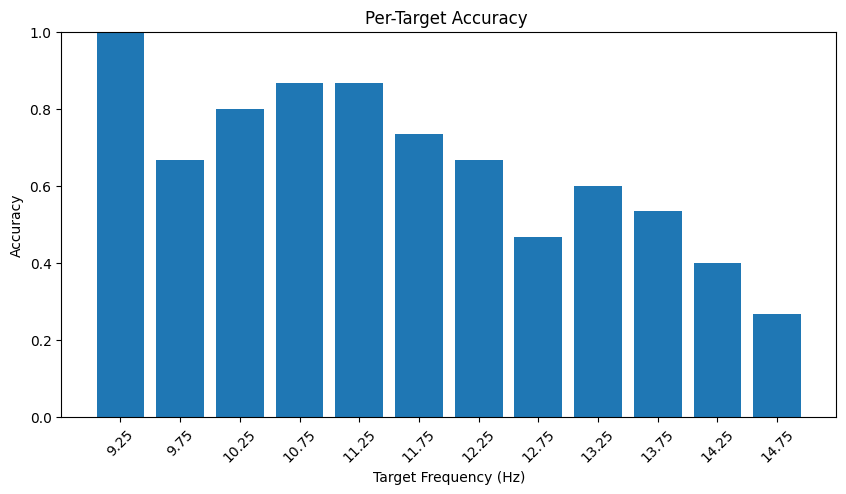

In [13]:
freqs = np.array(TARGET_FREQS)
accs = np.array(per_target_acc)

# Sort by frequency
sorted_idx = np.argsort(freqs)

freqs_sorted = freqs[sorted_idx]
accs_sorted = accs[sorted_idx]

# Plot
plt.figure(figsize=(10, 5))
plt.bar([str(f) for f in freqs_sorted], accs_sorted)

plt.xlabel("Target Frequency (Hz)")
plt.ylabel("Accuracy")
plt.title("Per-Target Accuracy ")
plt.ylim(0, 1.0)
plt.xticks(rotation=45)

plt.show()


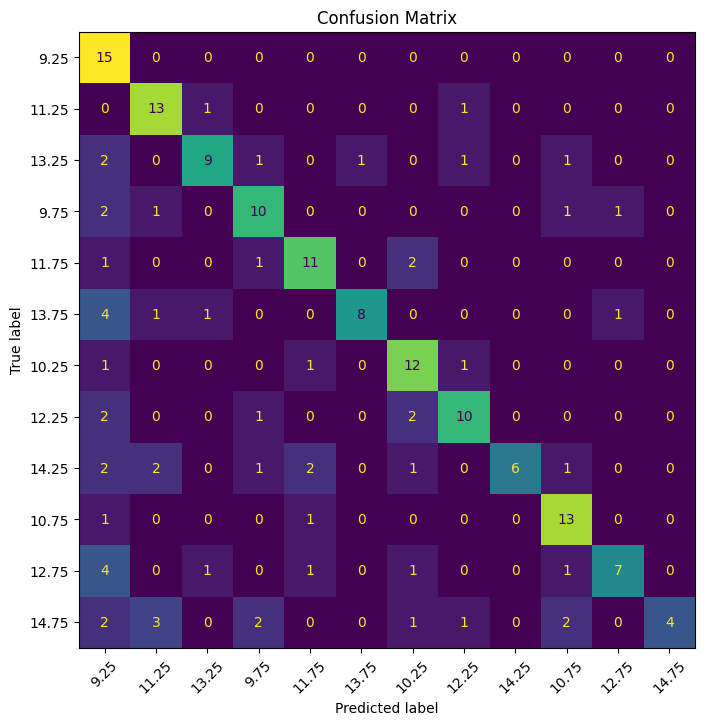

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for true_target in range(n_targets):
    for trial_idx in range(n_trials):
        trial = eeg[true_target, :, STIM_ONSET:, trial_idx]
        trial_filt = preprocess_trial(trial, fs=FS)
        pred = predict_fft(trial_filt,bins)

        y_true.append(true_target)
        y_pred.append(pred)

cm = confusion_matrix(y_true, y_pred, labels=list(range(n_targets)))

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"{f:.2f}" for f in TARGET_FREQS])
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.show()